A rota da Neuromante
==============================

#### Disciplina: Redes Neurais e Algoritmos Genéticos
#### Professor: Daniel R. Cassar
#### Autora: Sophia Alves

## I am not your rolling weels, I am the highway!
### Pela rota da neuromante, aí vamos nós!

Neste trabalho, nos foi proposto explorar mais sobre a estrada que nos leva as redes neurais. 

#### Redes neurais e MLPs
As redes neurais são ferramentas poderosissímas no contexto de aprendizado de máquina, estando situadas na sub-área de Deep Learning, onde desenvolve-se algoritmos para imitar e processar dados de forma similar ao sistema neural humano. Os neurônios são na verdade neurônios matemáticos baseados em dados de entrada, onde cada um tem seu peso, para ponderar cada valor de entrada, e seu viés, e uma função de ativação para ser aplicada e tornar o resultado não linear. A partir disso, pode-se formar camadas com vários neurônios, pesos e vieses, até que se chegue ao resultado final. O modelo que iremos utilizar é do tipo Perceptron, que utiliza um modelo matemático com vários dados de entrada e apenas um dado de saída. 

![img](https://www.deeplearningbook.com.br/wp-content/uploads/2018/01/neuronio-matematico.png)

Um maior interesse desse trabalho se encontra nas _multi layer perceptron_'s (MLPs), redes com mais de uma camada de neurônio, onde existe maior complexidade e maior adaptação do modelo às decisões a serem tomadas. 

![img](https://www.dtreg.com/uploaded/pageimg/MLFNwithWeights.jpg)

O grande coração das redes neurais está na sua adaptação aos melhores parâmetros durante o treino, o que a torna um grande e interesse modelo para as mais diversas aplicações. 

#### Processo de Treinamento
O treino da rede neural do tipo MLP se baseia em 5 momentos:

- Forward pass: primeiro momento onde a rede estruturada tem contato com os dados de entrada e segue a sequência de multiplicar pelos pesos, somar com os vieses e aplicar a função de ativação em todos os neurônios de todas as camadas existentes, entregando um resultado final (output y).
- Loss: cálculo da função de perda, geralmente MSE (mean squared error - diferença média dos quadrados, $(y_{real} - y_{previsto})^2$ que deverá ser minimizada, a fim de aumentar o desempenho da rede.
- Zeragem do gradiente: antes do backpropagation, é necessário zerar os gradientes do batch (lote) anterior, a fim de que ele não influencie o cálculo dos gradientes do batch atual, possibilitando a correta aprendizagem da rede acerca dos parâmetros. 
- Backpropagation: propagação no sentido reverso (previsão aos dados de entrada) do gradiente em relação ao valor de _output_. O gradiente é calculado em relação ao valor de saída e ajuda a rede a aprender sobre quais neurônios são mais influentes na rede. O gradiente é calculado partindo do valor de saída e todos os gradientes (derivadas parciais) são calculados pela ferramenta matemática da regra da cadeia.
- Atualização dos parâmetros: após a etapa do backpropagation, ocorre a atualização dos parâmetros do modelo, levando em conta os resultados da etapa anterior e a taxa de aprendizado. O papel de atualizar os parâmetros é do otimizador e diferentes otimizadores têm estratégias diferentes de atualização, cabendo à análise de qual exibe melhor performace no conjunto de dados trabalhado.

O treinamento de uma MLP é separado em épocas e batches (lotes). Uma época corresponde à passagem completa por todo o conjunto de dados de treino. Como treinar com todos os dados de uma vez é custoso computacionalmente, os dados podem ser divididos em batches: subconjuntos menores processados em sequência, onde a cada batch repete-se os cinco passos de treino descritos acima, atualizando os pesos gradualmente a cada lote. 

#### Regularização 

As redes neurais são tidas como excelentes modelos de aprendizado de máquina, sendo capazes de fazer boas previsões. Contudo, conforme a complexidade das redes aumenta, por exemplo com o número de camadas, pode acontecer de o modelo viciar nas informações do conjunto de treino, ao invés de aprender e ser capaz de fazer boas generalizações, fenômenos conhecido como _overfitting_ (sobreajuste): o modelo se adequa muito às informações dos dados de treino, exibindo bom desempenho no conjunto de dados de treino, mas desempenho fraco com novos dados. A regularização é uma técnica utilizada para evitar o sobreajuste, de forma a melhorar a capacidade gerar previsões precisas sobre um novo conjunto de dados. Os tipos de regularização mais utilizados no contexto de redes neurais são _early stopping_ (parada antecipada), _dropout_ e _weight decay_ (decaimento de peso) [10].

- _Early Stopping_: nessa técina a regularização acontece a partir da interrupção do treinamento quando a perda do conjunto de validação para de diminuir e passa a aumentar, indicando que o modelo está começando a entrar em _overfitting_, decorando os dados de treino ao invés de aprender padrões.

- _Drop out_: técnica de regularização de redes neurais por meio da desativação aleatória de certos neurônios por meio de uma taxa de _dropout_, que seria a probabilidade de um neurônio ser desativado. Essa estratégia possibilita o treino de diversas arquiteturas e evita que a rede dependa de neurônios específicos.

- _Weight decay_: evita _overfitting_ a partir da penalização de pesos muito grandes de grande ajuste aos dados de treinamento. A técnica adiciona um termo à função de perda, que corresponde à soma dos quadrados dos pesos do modelo, onde essa parcela da soma força a diminuição dos pesos a cada iteração.

#### Hiperparâmetros e sua otimização
Uma grande questão a ser observada durante o desenvolvimento de redes neurais do tipo MLP são os hiperparâmetros: variáveis determinadas antes do início do treino intrinsicamente ligadas ao comportamento e eficiência de um modelo. Estes são definidos antes do treino do modelo, diferentemente dos parâmetros, que são aprendidos durante o processo de treinamento. Para sabermos qual é a melhor escolha de hiperparâmetros para o nosso conjunto de dados, podemos fazer uma otimização dos hiperparâmetros usando alguma ferramenta que irá procurar pelas melhores "combinações" de hiperparâmetros que nos retornam as melhores métricas, as quais serão usadas para teste do modelo.

Nesse projeto, usaremos o framework Optuna, o qual opera na otimização automática de hiperparâmetros de maneira extremamente eficiente e flexível, sendo possível definir os hiperparâmetros de forma dinâmica (do tipo inteiro, flutuante ou categórico) e havendo grande compatibilidade com os principais frameworks de machine learning, especialmente PyTorch, que será usado no desenvolvimento da tarefa. O Optuna utiliza otimização bayesiana para busca dos hiperparâmetros, consistindo na construção de um modelo probabilístico que combina os hiperparâmetros visando ao melhor desempenho possível [9]. 

# Dataset escolhido: SUPERCONDUCTIVITY

O dataset escolhido foi o `Superconductivity`, presente no UCI Irvine Machine Learning Repository [1] O banco de dados possui diversas características de vários supercondutores e o alvo das previsões é a temperatura crítica destes. 

Fazendo uma breve introdução teórica, materiais supercondutores são aqueles que conduzem corrente elétrica com zero resistência, e esses exibem vastas e interessantes aplicações. Contudo, essa condução com zero resistência só existe abaixo de uma temperatura: a temperatura crítica (T$_c$). Essa temperatura geralmente é bem baixa (menor que o ponto de ebulição do nitrogênio) e os modelos científicos teóricos de previsão de T$_c$ não são tão consolidados e consensuais no meio científico. 

Com isso, diante de um conjunto de dados sobre supercondutores, iremos tentar prever a temperatura crítica dos supercondutores, tratando-se, portanto, de um problema de regressão, a partir de outras características desses materiais.

## Importando os dados 

In [1]:
import pandas as pd

df_dados = pd.read_csv("train.csv")

#### Realizando EDA - exploratory data analysis
Referência [4]

In [2]:
## Visualizando os primeiros elementos do dataframe criado com os dados 
df_dados.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [3]:
faltantes = df_dados.isnull().sum()
print(faltantes)
#Verificação de elementos faltantes

number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64


In [4]:
# Análise descritiva dos dados
df_dados.describe()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


#### Etapa de separação em grupo de treino e teste
Agora iremos separar o conjunto de dados em treino, validação e teste. O grupo de validação surge aqui como uma forma de obter os melhores hiperparâmetros na etapa de otimização, onde usaremos esse conjunto como um conjunto teste e verificar se o modelo está sofrendo sobreajuste e obter a combinação de hiperparâmetros que resultou na métrica de menor valor. 

Esse código foi retirado e adaptado do material da referência [2].

In [5]:
from sklearn.model_selection import train_test_split

SEMENTE_ALEATORIA = 37
TAMANHO_TESTE = 0.1
TAMANHO_VALIDACAO = 0.1

ATRIBUTOS = df_dados.columns.drop('critical_temp')
TARGET = ['critical_temp']

indices = df_dados.index
indices_treino_val, indices_teste = train_test_split(
    indices, test_size= TAMANHO_TESTE , random_state= SEMENTE_ALEATORIA
)

df_treino_val = df_dados.loc[indices_treino_val]
df_teste = df_dados.loc[indices_teste]

# Divisão do treino+validação em treino e validação
indices = df_treino_val.index
indices_treino, indices_val = train_test_split(
    indices, test_size=TAMANHO_VALIDACAO, random_state=SEMENTE_ALEATORIA)

df_treino = df_dados.loc[indices_treino]
df_val = df_dados.loc[indices_val]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values

X_val = df_val.reindex(ATRIBUTOS, axis=1).values
y_val = df_val.reindex(TARGET, axis=1).values

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values

#### Etapa da normalização
Para treinarmos nossa rede neural, é necessário tomar cuidado com a forma dos dados. MLPs são modelos sensíveis à escala das características (features) de entrada e a normalização evita o favorecimento de features com maiores magnitudes numéricas, possibilitando tratamento igualitário, acelera a convergência, reduzindo o tempo de treinamento e evita instabilidades numéricas. 

Os atributos foram normalizados com o MaxAbsScaler, devido à grande esparsidade dos dados, enquanto o target foi normalizado com o MinMaxScaler justamente por não possuir essa característica. Os valores esparsos (muito zeros) estão presentes em várias features, e aplicar o mesmo tipo de normalização que a do target deslocaria os valores e haveria perda de informação de esparsidade no dataset. Apenas os valores de treino foram fitados (.fit), a fim de evitar _data leckage_.

In [6]:
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler

normalizador_target = MinMaxScaler()
normalizador_atributos = MaxAbsScaler()

normalizador_target.fit(y_treino)
normalizador_atributos.fit(X_treino)

X_treino_norm = normalizador_atributos.transform(X_treino)
y_treino_norm = normalizador_target.transform(y_treino).ravel()

X_teste_norm = normalizador_atributos.transform(X_teste)
y_teste_norm = normalizador_target.transform(y_teste).ravel()

X_val_norm = normalizador_atributos.transform(X_val)
y_val_norm = normalizador_target.transform(y_val).ravel()

## Iniciando a construção da MLP
Para construir nossa rede, iremos usar a biblioteca PyTorch. É uma biblioteca amplamente utilizada para desenvolvimento de redes e, no contexto deste trabalho, foram utilizados quatro módulos principais: o `nn.Module`, classe base a partir da qual a arquitetura da rede foi definida; o `nn.Sequential`, utilizado para organizar as camadas da rede de forma sequencial; o `torch.optim`, responsável pelos otimizadores que atualizam os pesos durante o treino; e o `DataLoader` em conjunto com o `TensorDataset`, utilizados para dividir os dados em batches e alimentar a rede durante o treinamento. Além disso, o sistema de diferenciação automática do PyTorch, o autograd, foi fundamental para o cálculo dos gradientes durante o backpropagation, sendo acionado a cada chamada do loss.backward().

In [7]:
# Importando as bibliotecas
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

Para que os dados possam ser processados pelo PyTorch, é necessário convertê-los para o formato de tensor, estrutura de dados fundamental da biblioteca, equivalente aos arrays do NumPy mas com suporte a operações em GPU e cálculo automático de gradientes.
Além disso, os tensores foram definidos com precisão de 32 bits (float32) pois o PyTorch utiliza esse formato por padrão em suas operações — usar 64 bits geraria incompatibilidade com os parâmetros da rede, que são inicializados em 32 bits, causando erros durante o treino.

In [8]:
X_treino_norm = torch.tensor(X_treino_norm, dtype=torch.float32)
y_treino_norm = torch.tensor(y_treino_norm, dtype=torch.float32).view(-1, 1)

X_teste_norm = torch.tensor(X_teste_norm, dtype=torch.float32)
y_teste_norm = torch.tensor(y_teste_norm, dtype=torch.float32).view(-1, 1)

X_val_norm = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_norm = torch.tensor(y_val_norm, dtype=torch.float32).view(-1, 1)

In [9]:
NUM_ENTRADAS = X_treino_norm.shape[1]
NUM_TARGETS = 1

# Rede Neural - MLP
Agora iremos instanciar a classe MLP, que será responsável por guardar a estrutura da nossa rede. Aqui, passaremos os hiperparâmetros necessários para a arquitetura da rede, como número de neurônios e de camadas ocultas.

Primeiro, importamos a classe mãe `nn.Module`, originária do PyTorch e que será responsável pela formação da nossa rede neural, utilizando o método `super()._init_()`. Depois, iremos definir as funções de ativação possíveis de serem escolhidas pelo Optuna e executar a sequência de fazer a parte linear (multiplicar os dados de entrada pelos pesos e somar com os vieses), seguindo pela aplicação da função de ativação e passagem pelo _dropout_, que irá guardar a probabilidade de desativar um neurônio (também escolhida pelo Optuna), executando assim a regularização de dropout na rede. A função de perda escolhida foi a MSE (mean square error - erro quadrático médio), a qual possibilita maior aprendizado no treino, já que os valores de _output_ são analisados ao quadrado e impõe que o modelo adeque melhor seus parâmetros.

In [10]:
class MLP(nn.Module):
    def __init__(self, num_dados_entrada, camadas_ocultas, neuronios_por_camada,
                 num_targets, ativacao,dropout):
        
        super().__init__()
        
        ativacao_dic = {
        "relu":       nn.ReLU,
        "tanh":       nn.Tanh,
        "sigmoid":    nn.Sigmoid,
        "softplus":  nn.Softplus}
        
        funcao_ativacao = ativacao_dic[ativacao]

        #formando as camadas
        dados_entrada = num_dados_entrada 
        
        arquitetura = []
        
        for _ in range(camadas_ocultas):
            arquitetura.append(nn.Linear(dados_entrada, neuronios_por_camada))
            arquitetura.append((funcao_ativacao()))  # instancia uma nova a cada camada
            arquitetura.append(nn.Dropout(dropout))
            dados_entrada = neuronios_por_camada

        #camada de saída
        arquitetura.append(nn.Linear(dados_entrada, num_targets)) 
        
        # Converte a lista para nn.Sequential
        self.camadas = nn.Sequential(*arquitetura)
        self.fun_perda = nn.MSELoss()
    
    def forward(self, x):
        return self.camadas(x)

Agora iremos entrar na otimização dos hiperparâmetros usando o tão famoso `Optuna`. Ele se baseia em três partes principais: definição da função objetivo, que recebe um argumento _trial_, onde irá ser aplicado o método _.suggest_, que irá sugerir valores inteiros, flutuantes e categóricos de acordo com o requerido. Por exemplo, foi criada a variável n_camadas_ocultas e foi pedido ao optuna uma sugestão de inteiro no intervalo de 1 a 5. 
O mesmo ocorreu com os outros hiperparâmetros e a sugestão de cada um foi estabelecida a partir de intervalos e categorias existentes na literatura. 

Aqui no início da função vemos a aplicação de trial.suggest para vários hiperparâmetros, então é conveniente entender sobre a aplicação de cada um, seja na arquitetura ou na aprendizagem durante o treino da rede.

#### Hiperparâmetros referentes à estrutura da rede 
- n_camadas_ocultas: camadas ocultas da rede MLP. Os valores a serem sugeridos devem ser inteiros entre 1 e 5. Devido à quantidade de dados (21263 amoatras), optou-se por estender o limite máximo a 5. Essa sugestão veio da referência [2] e [].
- n_neuronios_por_camadas: quantidade de neurônios em cada camada oculta. A sugestão foi de valores no intervalo de 10 a 100, também advindos das referências [2] e [].
- funcoes_ativacao: funções de ativação a serem escolhidas e aplicadas na rede a cada vez que se passa por um neurônio, trazendo uma não-linearidade à rede. As sugestões foram baseadas nas funções mais usadas pela comunidade ao modelar MLPs, além de ser sugerido na literatura [].
- _dropout_: probabilidade de um neurônio ser desativado na rede, sendo isso uma estratégia de regularização e melhora o desempenho da rede. Valores entre 0.1 e 0.5 são os mais utilizados.

#### Hiperparâmetros referentes ao aprendizado da rede 
- taxa_de_aprendizado: _learning rate_ a ser aplicada no otimizador.
- tamanho_lote (batch): tamanho dos lotes que os treinos devem ocorrer. Como passar por todos os dados de uma vez é custoso, é mais adequado separar em grupos menores (lotes) e computar a métrica após passagem de cada lote. Foram sugeridas potências de 2 (16, 32, 64, 128) por questões de eficiência de hardware.
- paciencia: valores de época suportados pela estratégia de parada antecipada antes de concluir que está ocorrendo overfitting. No caso, quantas épocas consecutivas o modelo pode continuar treinando sem que a função de perda no conjunto de validação apresente melhora. Se o limite for atingido, o treino é interrompido.
- otimizador: responsável pela atualização dos parâmetros. Os mais comuns são o Adam (Adaptive Moment Estimation), SGD (descida estocástica do gradiente) e RMSProp (Root Mean Square Prop). Estes otimizadores serão explicados com mais detalhes em seções abaixo.
- _weight_decay_: estratégia de regularização L2, que penaliza pesos muito grandes no modelo. A técnica adiciona uma penalidade à função de perda proporcional à magnitude dos pesos, forçando a rede a manter valores menores e mais bem distribuídos, o que é fundamental para evitar o sobreajuste.


### Otimizadores
Os otimizadores são elementos que fazem um ajuste fino nos parâmetros durante a etapa de aprendizado do modelo, com ação principal na diminuição da função de perda do modelo, melhorando a performance. Esses elementos melhoram o processo de aprendizado a partir da mudança dos parâmetros `pesos e viéses`. Os otimizadores que foram colocados como sugestão ao Optuna nesse trabalho foram SGD (Stochastic Gradient Descent), RMSprop e Adam.

- SGD (Stochastic Gradient Descent): atualiza os pesos diretamente na direção oposta ao gradiente da função de perda, multiplicado pela taxa de aprendizado, após a passagem pelos dados do lote. É o método mais simples e interpretável, mas pode ser lento para convergir e sensível à taxa de aprendizado. 

- RMSprop: adapta a taxa de aprendizado individualmente para cada parâmetro, dividindo-a pela média quadrática dos gradientes recentes. Isso torna o processo mais estável em problemas com gradientes muito variáveis.

- Adam: é considerado o mais completo entre os três, o Adam combina vantagens dos dois anteriores: taxa de aprendizado adaptativa por parâmetro e uso de momento. A taxa de aprendizado adaptativa por parâmetro se baseia em atualizações dos parâmetros com base no seu gradiente, em que parâmetros com gradientes grandes recebem atualizações menores e parâmetros com gradientes pequenos recebem atualizações maiores. O uso de momento é uma memória dos gradientes passados que suaviza a direção das atualizações, evitando oscilações bruscas durante o aprendizado. É amplamente considerado o otimizador mais robusto na prática, o que foi confirmado nos resultados deste trabalho.



#### Função Objetivo 
Após essa explicação podemos avançar na função objetivo. O optuna irá sugerir cada um dos hiperparâmetros e a rede será treinada [6]. Com isso, a instância do modelo foi criada substituindo os argumentos pelos valores escolhidos pelo optuna, seguindo pela aplicação do otimizador para que o processo de treino prossiga. 

O treino ocorre em lotes e para isso, usa-se a função TensorDataset para pegar os dados e aplicar eles na função DataLoader, que irá dividir nossos dados e formar os lotes [14].

Com isso, prossegue-se com o treino em batches para 200 épocas, em que em cada uma o gradiente é zerado pelo otimizador a cada iteração. Isso é feito devido ao caráter padrão do PyTorch em acumular os gradientes em cada iteração, então para não ocorrer interferência de um aprendizado no outro, é necessário zerar os gradientes.

Prossegue-se com a predição e calcula-se a função de perda (MSELoss).
Depois, é feita a etapa do _backpropagation_, onde o PyTorch calcula automaticamente os gradientes de cada peso e viés e a rede consegue observar quais parâmetros devem ser atualizados.

Por fim, o otimizador cuida da atualização dos parâmetros, com o método _.step_, utilizando os gradientes calculados na etapa anterior e a taxa de aprendizado para ajustar os pesos e vieses.

In [11]:
def funcao_objetivo(trial):
    n_camadas_ocultas = trial.suggest_int("n_camadas_ocultas", 1, 5)
    n_neuronios_por_camadas = trial.suggest_int("neuronios_por_camada", 10,100)
    taxa_de_aprendizado = trial.suggest_float("taxa_de_aprendizado",0.00001, 0.1, log = True)
    funcoes_ativacao = trial.suggest_categorical("funcao_ativacao", 
                                            ["relu", "tanh", "sigmoid", "softplus"])
    tamanho_lote = trial.suggest_categorical("tamanho_lote", [16, 32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    paciencia = trial.suggest_int("paciencia", 10, 30)
    otimizador = trial.suggest_categorical("otimizador", ["adam", "sgd", "rmsprop"])
    weight_decay = trial.suggest_float("weight_decay", 0.00001, 0.01, log=True)

    modelo_rede = MLP(num_dados_entrada= NUM_ENTRADAS,
        camadas_ocultas= n_camadas_ocultas,
        neuronios_por_camada=n_neuronios_por_camadas,
        num_targets= NUM_TARGETS, ativacao= funcoes_ativacao, dropout = dropout)

    otimizadores = {
    "adam" : torch.optim.Adam(modelo_rede.parameters(), lr=taxa_de_aprendizado,
    weight_decay=weight_decay),
    "sgd": torch.optim.SGD(modelo_rede.parameters(),lr=taxa_de_aprendizado,
    weight_decay=weight_decay),
    "rmsprop": torch.optim.RMSprop(modelo_rede.parameters(),lr=taxa_de_aprendizado,
    weight_decay=weight_decay)}

    otimizador_escolhido = otimizadores[otimizador]

    dataset = TensorDataset(X_treino_norm, y_treino_norm)
    loader  = DataLoader(dataset, batch_size=tamanho_lote, shuffle=True)

    melhor_perda = float("inf")
    contador = 0 

    for epoca in range(200):
        modelo_rede.train() #etapa de treino
        for X_lote, y_lote in loader:
            otimizador_escolhido.zero_grad()
            y_pred = modelo_rede(X_lote)
            loss = modelo_rede.fun_perda(y_pred, y_lote)
            loss.backward()
            otimizador_escolhido.step()
            
        modelo_rede.eval() #etapa da validação!!!
        with torch.no_grad(): #torch.no_grad não registra as informações para cálculo de gradiente
            y_pred_val = modelo_rede(X_val_norm)
            perda_val  = modelo_rede.fun_perda(y_pred_val, y_val_norm)
        # early stopping
        if perda_val < melhor_perda:
            melhor_perda = perda_val
            contador = 0
        else:
            contador += 1
        if contador >= paciencia:
            break
            
    return melhor_perda.item()

Observe que após o treino em cada época é feita a validação. Nessa etapa tomamos maior consciência da necessidade de separar um conjunto de validação, pois este que irá se comportar como conjunto de teste antes do teste, e possibilita a aplicação da _early stopping_ e melhor adequação do modelo.


Depois de criarmos a função objetivo, que nos retorna a função de perda, criamos um estudo, onde cada trial (tentativa) será armazenado em um arquivo `.db`. O argumento _load_if_exists_ serve para carregar o arquivo _.db_ de estudos passados [6].

In [12]:
from optuna import create_study

estudo = "mlp_neuromante"

objeto_de_estudo = create_study(
    direction="minimize",
    study_name=estudo,
    storage=f"sqlite:///{estudo}.db",
    load_if_exists=True)

[I 2026-04-06 23:16:17,137] Using an existing study with name 'mlp_neuromante' instead of creating a new one.


Por último, aplica-se o método _optimize_ para rodar um estudo, fornecendo a função objetivo a ser otimizada e com 142 trials. Essa quantidade de trials foi escolhida para garantir um bom espaço de otimização. Como o arquivo .db já existe e é fornecido junto ao notebook, não precisamos rodar a célula com o _.optimize_, mas iremos carregar o estudo utilizando o _load_study_. 

Carregando o estudo com o _load_study_, do próprio optuna:

In [13]:
from optuna import load_study

objeto_de_estudo = load_study(
    study_name="mlp_neuromante",
    storage="sqlite:///mlp_neuromante.db"
)

print(f"Trials já completos: {len(objeto_de_estudo.trials)}")

Trials já completos: 142


Terminados todos os trials, podemos obter o trial que melhor (menor) métrica e seus hiperparâmetros. Esses valores obtidos serão usados para treinar a rede e fazer oficialmente o teste.

In [14]:
melhor_trial = objeto_de_estudo.best_trial

print(f"Número do melhor trial: {melhor_trial.number}")
print(f"Parâmetros do melhor trial: {melhor_trial.params}")
print(f"MSE: {melhor_trial.value}")

Número do melhor trial: 138
Parâmetros do melhor trial: {'n_camadas_ocultas': 5, 'neuronios_por_camada': 100, 'taxa_de_aprendizado': 0.0003169104878304311, 'funcao_ativacao': 'relu', 'tamanho_lote': 128, 'dropout': 0.10051694926883484, 'paciencia': 27, 'otimizador': 'adam', 'weight_decay': 1.2477302268360797e-05}
MSE: 0.003881084732711315


A partir desses resultados, já podemos concluir pontos importantes sobre o processo de otimização. Geralmente, altas quantidades de camadas ocultas e neurônios por camadas tendem a conduzir o modelo para o sobreajuste. 

Mas por que isso não ocorreu? 

Pois o nosso problema de tentar prever a temperatura crítica de supercondutores é um problema não linear e complexo da área de materiais. O fato de o resultado dos hiperparâmetros relacionados com a arquitetura da rede serem exatamente os limites máximos impostos no Optuna induz que uma maior complexidade e maior quantidade de parâmetros são fundamentais para permitir um bom processo de aprendizado.

A cereja do bolo está na regularização: uma grande quantidade de parâmetros trabalha em conjunto com as regularizações aplicadas (_dropout, early stopping_ e L2). 

A aplicação do _dropout_ evita que a rede dependa de neurônios específicos, tornando o aprendizado mais robusto. O decaimento dos pesos (_weight_decay_, relacionado com a regularização L2) mostra que os pesos estão sendo penalizados a cada passo e a imposição de valores mais baixos impede o modelo de decorar e se ajustar ao treino. Além disso, a paciência (tolerância) explicita que o modelo foi bem acompanhado durante as épocas, mostrando a parada no momento que ele começasse a se sobreajustar aos dados de treino.

Com isso, o Optuna percebeu que deveria aumentar a complexidade da rede dada a complexidade do próprio problema, alinhando uma grande quantidade de hiperparâmetros (camadas ocultas e neurônios) com estratégias de regularização, que preveniram a ocorrência de _overfitting_.

### Avaliação do processo de otimização utilizando o recurso de visualização do próprio Optuna

Podemos analisar a importância de cada um dos hiperparâmetros no ajuste do modelo e ainda os valores de otimização. A referência [5] abriga a documentação desse módulo. 

In [15]:
import optuna.visualization as vis 

vis.plot_param_importances(objeto_de_estudo) 

In [16]:
vis.plot_optimization_history(objeto_de_estudo)

Com esses gráficos de visualização do próprio optuna, podemos extrair informações riquíssimas da nossa rede.

O primeiro gráfico demonstra o que foi discutido acima: boa parte de importâncias de hiperparâmetros está concentrada nos hiperparâmetros Otimizador, Weight Decay e Dropout, apontando que a arquitetura profunda da rede depende das restrições impostas pelas técnicas de regularização. Curiosamente, o número de camadas ocultas teve menor importância, indicando que o controle do modelo é mais importante que o tamanho da própria rede. 

Além disso, o histórico de otimização demonstra a eficiência da busca Bayesiana do Optuna: o algoritmo rapidamente encontrou a "região boa" e passou o resto da otimização fazendo um ajuste fino e exploração contínua, arriscando combinações para garantir que não ficou preso em um mínimo local. 

### Treinando a rede com os hiperparâmetros já otimizados

A partir dos valores obtidos com o _melhor_trial.params_, vamos treinar nosso modelo com os hiperparâmetros encontrados pelo optuna. 

In [17]:
melhores_params = melhor_trial.params

n_camadas_oc = melhores_params["n_camadas_ocultas"]
neuronios_camada = melhores_params["neuronios_por_camada"]
taxa_aprendizado = melhores_params["taxa_de_aprendizado"]
func_ativacao = melhores_params["funcao_ativacao"]
lote = melhores_params["tamanho_lote"]
dropout = melhores_params["dropout"]
paciencia = melhores_params["paciencia"]
otimizador_final = melhores_params["otimizador"]
weight_decay = melhores_params["weight_decay"]

modelo_final = MLP(
    num_dados_entrada=NUM_ENTRADAS,
    camadas_ocultas=n_camadas_oc,
    neuronios_por_camada=neuronios_camada,
    num_targets=NUM_TARGETS,
    ativacao=func_ativacao,
    dropout=dropout)

otimizadores = {
    "adam":    torch.optim.Adam(modelo_final.parameters(), lr=taxa_aprendizado, weight_decay=weight_decay),
    "sgd":     torch.optim.SGD(modelo_final.parameters(),  lr=taxa_aprendizado, weight_decay=weight_decay),
    "rmsprop": torch.optim.RMSprop(modelo_final.parameters(), lr=taxa_aprendizado, weight_decay=weight_decay)
}
otimizador_escolhido = otimizadores[otimizador_final] 

Agora já podemos unir o conjunto treino e validação, fazendo um único conjunto final de treino, dado que a otimização dos hiperparâmetros já foi feita. A união é feita com o método _.cat_, que concatena os dois conjuntos.

Após essa junção, aplica-se o TensorDataset e o DataLoader nesses dados a fim de formar os lotes e fazer ro treino de maneira gradual.

In [18]:
# Une treino + validação
X_final = torch.cat([X_treino_norm, X_val_norm], dim=0)
y_final = torch.cat([y_treino_norm, y_val_norm], dim=0)

dataset_final = TensorDataset(X_final, y_final)
loader_final  = DataLoader(dataset_final, batch_size= lote, shuffle=True)

Nesse momento, iremos realizar o mesmo processo descrito na seção de `função objetivo`. 
A cada época, o valor da métrica é armazenada em uma lista, que será usada para plotagem da curva de aprendizagem. 

Acompanharemos a curva de aprendizado do modelo, observando a perda (MSE) por época. 

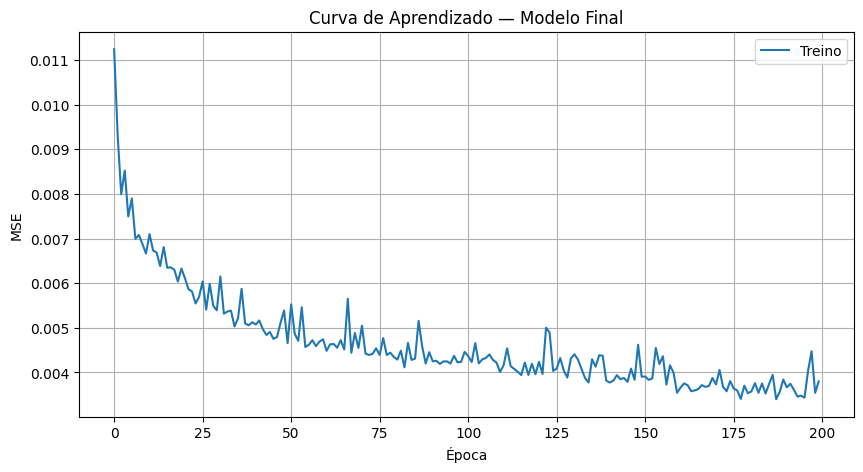

In [19]:
#Treino
historico_treino = []

for epoca in range(200):
    modelo_final.train()
    for X_lote, y_lote in loader_final:
        otimizador_escolhido.zero_grad()
        y_pred = modelo_final(X_lote)
        loss = modelo_final.fun_perda(y_pred, y_lote)
        loss.backward()
        otimizador_escolhido.step()
    
    modelo_final.eval()
    with torch.no_grad():
        perda_treino = modelo_final.fun_perda(modelo_final(X_final), y_final)
    
    historico_treino.append(perda_treino.item())


# Plot
plt.figure(figsize=(10, 5))
plt.plot(historico_treino, label="Treino")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de Aprendizado — Modelo Final")
plt.legend()
plt.grid(True)
plt.show()

#### Breve análise da curva de aprendizado
A curva de aprendizado (em azul) mostra a evolução do erro quadratico médio (MSE) da MLP ao longo das 200 épocas. Analisando o gráfico, é possível ver que há uma rápida convergência inicial, dada pela queda abrupta e íngreme, demonstrando que o modelo conseguiu captar rapidamente os padrões mais óbvios dos dados. O fato de a curva não é perfeitamente lisa é uma consequência natural das escolhas dos hiperparâmetros. As razões para isso são: 
1) Uso de mini-lotes faz com que o erro seja calculado a partir de cada pedaço por vez.
2) Atuação do Adam, que tenta ajustar o passo dinamicamente.
3) Presença de dropout, que força a rede a não decorar, e sim aprender.

A curva passa a estabilizar a partir da época 150, onde a rede já atingiu sua capacidade máxima de aprendizado do conjunto de treino e passa a convergir para seu erro mínimo possível. 

Finalmente, faremos a etapa de teste para avaliar se nossa rede é eficiente para o nosso problema de temperatura crítica de supercondutores. Aqui foi feita uma desnormalização, a fim de que possamos comparar os dados na própria escala Kelvin de temperatura e ter maior dimensão do desempenho do modelo. 

In [20]:
# Teste
modelo_final.eval()
with torch.no_grad():
    y_pred_teste = modelo_final(X_teste_norm)

y_pred_kelvin = normalizador_target.inverse_transform(y_pred_teste.numpy())
y_real_kelvin = normalizador_target.inverse_transform(y_teste_norm.numpy())

mse  = np.mean((y_pred_kelvin - y_real_kelvin)**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_pred_kelvin - y_real_kelvin))

print(f"MSE:  {mse:.4f} K²")
print(f"RMSE: {rmse:.4f} K")

MSE:  138.7635 K²
RMSE: 11.7798 K


# Comparação com outros modelos

Agora, vamos comparar o desempenho de outros modelos com o desempenho da nossa rede e analisar o quão bem cada modelo consegue se adaptar ao problema de temperatura crítica de supercondutores.

### Modelos escolhidos: 
- Lasso Regression
- Random Forest

Os modelos escolhidos foram o Lasso Regression, para fazer uma comparação da rede com um modelo linear e mostrar que o problema que temos não é de natureza linear. O outro foi o Random Forest, um algoritmo robusto e não linear, baseado na construção de múltiplas árvores de decisão. A escolha foi feita devido à sua característica de conseguir capturar informações complexas nos atributos sem necessidade de normalização. A ideia é verificar se a capacidade de abstração profunda da nossa rede neural (MLP) realmente traz um diferencial competitivo para prever a temperatura crítica dos supercondutores, ou se um bom algoritmo clássico baseado em árvores já seria suficiente.

### Lasso
O Lasso é um modelo linear que aplica regularização L1 no treino. Essa técnica de regularização, que se torna o seu diferencial nos modelos lineares, zera os coeficientes de features de pouca importância, fazendo uma espécie de seleção de atributos. É uma interessante escolha dadas as dimensões do conjunto de dados, servindo também para analisar a importância de cada atributo nas previsões [7].

Para manter o mesmo padrão nos três odelos comparados, iremos fazer a otimização com o Optuna dos hiperparâmetros desse modelo. Por se tratar de um modelo simples, possui apenas dois hiperparâmetros: n_alphas e max_inter.

- alpha: constante que multiplica o termo de penalidade L1, controlando a intensidade da regularização. Quanto maior o alpha, mais forte é a penalização e mais coeficientes são forçados a zero.
- max_iter: número máximo de iterações permitidas para que o algoritmo do modelo consiga convergir.

In [21]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

X_treino_val = np.concatenate([X_treino, X_val])
y_treino_val = np.concatenate([y_treino, y_val])

def funcao_objetivo_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 10, log=True)
    max_iter = trial.suggest_int("max_iter", 1000, 5000)
    
    modelo = Lasso(alpha=alpha, max_iter=max_iter, tol = 0.01 ,random_state=37)
    metricas = cross_val_score(modelo, X_treino_val, y_treino_val.ravel(),
                               scoring="neg_root_mean_squared_error", cv=5)
    return -metricas.mean()

In [22]:
from optuna import load_study

objeto_de_estudo2 = load_study(
    study_name="lasso_study",
    storage="sqlite:///lasso_study.db")

print(f"Trials já completos: {len(objeto_de_estudo2.trials)}")

Trials já completos: 16


In [23]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignora os avisos de convergência 
warnings.filterwarnings("ignore", category=ConvergenceWarning)

#objeto_de_estudo2.optimize(funcao_objetivo_lasso, n_trials=10)

In [24]:
print(f"Trials já completos: {len(objeto_de_estudo2.trials)}")

melhor_lasso = objeto_de_estudo2.best_trial
melhor_params_lasso = melhor_lasso.params
print(melhor_params_lasso)

Trials já completos: 16
{'alpha': 1.057057641151799e-05, 'max_iter': 3848}


In [ ]:
lasso_final = Lasso(
    alpha = melhor_params_lasso["alpha"],
    max_iter = melhor_params_lasso["max_iter"],
    tol = 0.01,
    random_state=37)

lasso_final.fit(X_treino_val, y_treino_val.ravel())
y_pred_lasso = lasso_final.predict(X_teste)
rmse_lasso = np.sqrt(np.mean((y_pred_lasso - y_teste.ravel())**2))
print(f"RMSE do modelo Lasso: {rmse_lasso} K")

## Floresta Aleatória

Como já citado, o modelo da Floresta Aleatória é um modelo robusto e não linear que será usado para comparação direta com a rede neural que desenvolvemos, a fim de que possamos concluir se, para o trabalho de supercondutores, um modelo mais complexo, como a rede neural, realmente é necessário ou se um algortimo mais clássico consegue generalizar bem [8].

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

X_treino_val = np.concatenate([X_treino, X_val])
y_treino_val = np.concatenate([y_treino, y_val])

A floresta aleatória possui os seguintes hiperparâmetros, que também serão otimizados para fazer uma comparação justa entre os três modelos no quesito de escolha de hiperparâmetros.

- n_estimators: número total de árvores que compõem a floresta.
- min_samples_split: número mínimo de amostras em um nó (galho da árvore) para que haver divisão (split).
- min_samples_leaf: número mínimo de amostras que devem existir em um nó folha.
- max_features: proporção máxima de atributos que cada árvore irá considerar aleatoriamente na hora de fazer uma divisão. 


In [ ]:
def funcao_objetivo3(trial):

    parametros = {
        "n_estimators": trial.suggest_int("num_arvores", 5, 150),
        "min_samples_split": trial.suggest_int("min_exemplos_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_exemplos_folha", 1, 20),
        "max_features": trial.suggest_float("num_max_atributos", 0, 1),
        "n_jobs": -1,
        "bootstrap": True,
        "random_state": 37,
    }
    modelo = RandomForestRegressor(**parametros)

    metricas = cross_val_score(modelo, X_treino_val, y_treino_val.ravel(),
                               scoring="neg_root_mean_squared_error", cv=5)

    return -metricas.mean()

#### Criação/carregamento do estudo - floresta aleatória

In [ ]:
from optuna import load_study

objeto_de_estudo3 = load_study(
    study_name="floresta_aleatoria_study",
    storage="sqlite:///floresta_aleatoria_study.db"
)

print(f"Trials já completos: {len(objeto_de_estudo3.trials)}")

In [ ]:
#objeto_de_estudo3.optimize(funcao_objetivo3, n_trials=130)

#### Melhores parâmetros

In [ ]:
melhor_floresta = objeto_de_estudo3.best_trial

melhor_params_floresta = melhor_floresta.params
melhor_params_floresta

In [ ]:
floresta_final = RandomForestRegressor(
    n_estimators=melhor_params_floresta["num_arvores"],
    min_samples_split=melhor_params_floresta["min_exemplos_split"],
    min_samples_leaf=melhor_params_floresta["min_exemplos_folha"],
    max_features=melhor_params_floresta["num_max_atributos"],
    random_state=37,
    n_jobs=-1)

floresta_final.fit(X_treino_val, y_treino_val.ravel())
y_pred_floresta = floresta_final.predict(X_teste)
rmse_floresta = np.sqrt(np.mean((y_pred_floresta - y_teste)**2))
print(f"RMSE do modelo Floresta Aleatória: {rmse_floresta} K")

# Comparações 
Agora vamos comparar os RMSE's obtidos em cada um dos modelos:

In [ ]:
print(f"RMSE - Rede MLP: {rmse:.4f}")
print()
print(f"RMSE - Lasso: {rmse_lasso:.4f}")
print()
print(f"RMSE - Floresta Aleatória: {rmse_floresta:.4f}")
print()

Com isso, concluimos que a rede neural MLP desenvolvida teve uma excelente e a melhor performance, em comparação com os outros modelos, mostrando que, no caso complexo e não linear de prever a temperatura crítica de supercondutores, modelos lineares, como o Lasso não se adequam devido à própria natureza do problema, e o modelo mais robusto e não linear usado não conseguiu captar a essência e as nuances do problema, provando que as redes neurais conseguem absorver mais padrões dos dados e mais adequadas a esses problemas de grande complexidade e não lineares.

A otimização dos hiperparâmetros da rede é extremamente necessária, devido à quantidade de hiperparâmetros existentes e os valores destes afetam fortemente o desempenho da rede. O Optuna se mostrou um excelente otimizador desses hiperparâmetros, com um excelente retorno na visualização da importância dos parâmetros no treino da rede, esclarecendo que o otimizador e as estratégias de regularização são cruciais no aprendizado e desempenho da rede, e ainda no histórico de otimização. 

Os outros modelos também tiveram seus hiperparâmetros otimizados pelo optuna. O modelo Lasso já demonstrou, na própria otimização, impróprio para o problema, onde os _trials_ tinham muito problemas para rodar devido a problemas de convergência do algoritmo de otimização do próprio Lasso, escancarando a natureza não linear da temperatura crítica. A floresta aleatória não conseguiu generalizar padrões dos dados e teve um desempenho bem distuante do desempenho da rede, estando mais próximo do Lasso do que da própria rede.

# Referências 

[1] DATASET: https://archive.ics.uci.edu/dataset/464/superconductivty+data

[2] Materiais de aula do professor Daniel Cassar da disciplina de Redes Neurais e Algoritmos Genéticos. 

[3] A. Géron, Hands-On Machine Learning with Scikit-Learn and Pytorch: Concepts, Tools, and Techniques to Build In: Concepts, Tools, and Techniques to Build Intelligent Systems, O’Reilly Media, US, 2025.

[4] EDA : https://medium.com/@mirabuhuraira/exploratory-data-analysis-and-preprocessing-for-neural-networks-a-step-by-step-guide-1a1cfa327a92

[5] optuna.visualization — Optuna 4.8.0 documentation. Disponível em: <https://optuna.readthedocs.io/en/stable/reference/visualization/index.html>. Acesso em: 7 abr. 2026.

‌[6] optuna — Optuna 4.8.0 documentation. Disponível em: <https://optuna.readthedocs.io/en/stable/reference/optuna.html>. Acesso em: 7 abr. 2026.

[7] sklearn.linear_model.Lasso. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html>.

‌
[8] SCIKIT-LEARN. 3.2.4.3.2. sklearn.ensemble.RandomForestRegressor — scikit-learn 0.20.3 documentation. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html>.

‌[9] LEO, C. Machine Learning Optimization with Optuna | TDS Archive. Disponível em: <https://medium.com/data-science/machine-learning-optimization-with-optuna-57593d700e52>.

‌[10] PH.D, J. M.; KAVLAKOGLU, E. Regularização. Disponível em: <https://www.ibm.com/br-pt/think/topics/regularization>.

‌[11] DASARI, V. Multilayer Perceptron and its Hyperparameter Tuning. Disponível em: <https://medium.com/@vijaikdasari/multilayer-perceptron-and-its-hyperparameter-tuning-deedfbca2d1b>.

[12] Índice - Deep Learning Book. Disponível em: <https://www.deeplearningbook.com.br/indice/>.

‌[13] KARAN_BHUTANI. Hyperparameter Tuning for Smart People: Why Optuna Beats GridSearchCV and RandomizedSearchCV. Disponível em: <https://medium.com/@karanbhutani477/hyperparameter-tuning-for-smart-people-why-optuna-beats-gridsearchcv-and-randomizedsearchcv-9b9924620215>.

‌[14] GEEKSFORGEEKS. PyTorch DataLoader. Disponível em: <https://www.geeksforgeeks.org/deep-learning/pytorch-dataloader/>.

‌
‌